**Aula 05 - Regressão Logística**

_Exercícios de Treinamento de Modelos Lineares._

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ageron/handson-ml3/blob/main/04_training_linear_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ageron/handson-ml3/blob/main/04_training_linear_models.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

# Setup

O projeto requer Python 3.7 ou acima:

In [53]:
import sys

assert sys.version_info >= (3, 7)

Também requer Scikit-Learn ≥ 1.0.1:

In [54]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

Definindo as fontes dos gráficos, apenas para estética:

In [55]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

Define a função `save_fig()`, que gravará as imagens geradas para os gráficos na pasta `images/training_linear_models`. Assim todas as imagens plotadas abaixo, ficam disponíveis para download.

In [56]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "training_linear_models"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# Regressão Logística

A Regressão Logística costuma ser usada para estimar a probabilidade de uma instância pertencer a certa classe. Por exemplo: Qual a probabilidade deste email ser um spam?

Trata-se de um Classificador Binário.

## Estimando Probabilidades


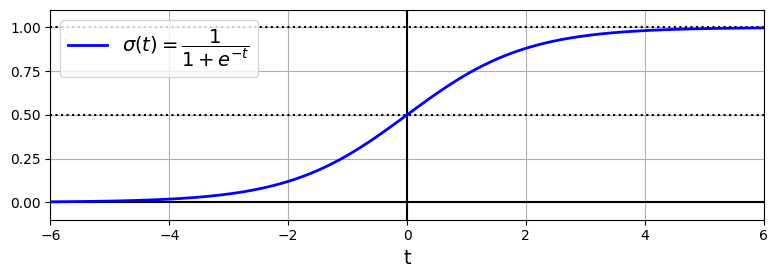

In [57]:
import numpy as np

lim = 6
t = np.linspace(-lim, lim, 100)
sig = 1 / (1 + np.exp(-t))

plt.figure(figsize=(8, 3))
plt.plot([-lim, lim], [0, 0], "k-")
plt.plot([-lim, lim], [0.5, 0.5], "k:")
plt.plot([-lim, lim], [1, 1], "k:")
plt.plot([0, 0], [-1.1, 1.1], "k-")
plt.plot(t, sig, "b-", linewidth=2, label=r"$\sigma(t) = \dfrac{1}{1 + e^{-t}}$")
plt.xlabel("t")
plt.legend(loc="upper left")
plt.axis([-lim, lim, -0.1, 1.1])
plt.gca().set_yticks([0, 0.25, 0.5, 0.75, 1])
plt.grid()
save_fig("logistic_function_plot")
plt.show()

## Dataset e Modelo

Vamos utilizar o conjunto de dados da Flor Íris para ilustrar a Regressão Logística. É um conjunto de dados conhecido, que tem a informações de 150 **flores Íris**, de 3 espécies diferentes:  
- Iris setosa;
- Iris versicolor;
- Iris virginica.

In [58]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
list(iris)

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [59]:
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [60]:
iris.data.head(3)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


In [61]:
iris.target.head(3)  #as instâncias não estão embaralhadas

,target
0,0
1,0
2,0


In [62]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

**Características Chave utilizada nesta Classificação**

- Iris Virginica
A largura da pétala varia de 1,4cm a 2,5 cm

- Demais Espécies
A largura da pétala varia de 0,1cm a 1,8 cm

In [63]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X = iris.data[["petal width (cm)"]].values
y = iris.target_names[iris.target] == 'virginica'
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

LogisticRegression(random_state=42)

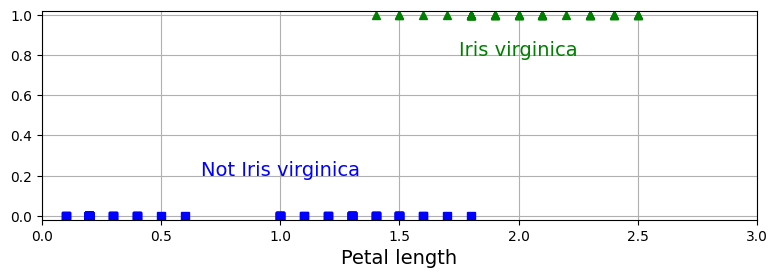

In [64]:
x0, x1 = np.meshgrid(np.linspace(2.9, 7, 500).reshape(-1, 1),
                     np.linspace(0.8, 2.7, 200).reshape(-1, 1))
X_new = np.c_[x0.ravel(), x1.ravel()]  # one instance per point on the figure

plt.figure(figsize=(8, 3))
#plt.plot(X_train[y_train == 0], X_train[y_train == 0], "bs")
#plt.plot(X_train[y_train == 1], X_train[y_train == 1], "g^")
plt.plot(X_train[y_train == 0], y_train[y_train == 0], "bs")
plt.plot(X_train[y_train == 1], y_train[y_train == 1], "g^")
plt.text(1, 0.2, "Not Iris virginica", color="b", ha="center")
plt.text(2, 0.8, "Iris virginica", color="g", ha="center")
plt.xlabel("Petal length")

plt.axis([0, 3, -0.02, 1.02])
plt.grid()
save_fig("iris_data")
plt.show()

In [65]:
log_reg.predict([[1.0], [1.7], [1.5], [2.0]])

array([False,  True, False,  True])

### FIM DA 1ª DA DEMONSTRAÇÃO - voltar aos slides

#Função de Custo e Regularização

Aqui temos a Log Loss plotada de forma genérica, sem um modelo específico.

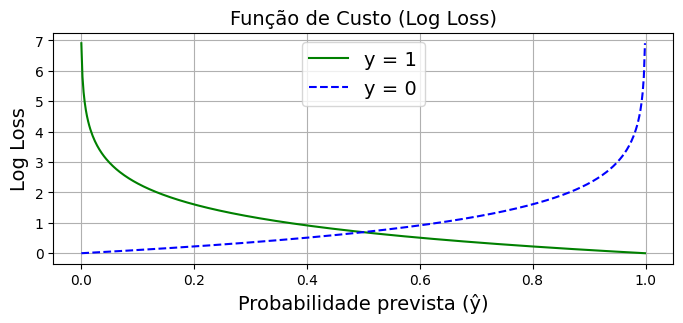

In [66]:
# Probabilidades de 0.001 a 0.999
p = np.linspace(0.001, 0.999, 500)

# Log loss para y=1
loss_y1 = -np.log(p)

# Log loss para y=0
loss_y0 = -np.log(1 - p)

plt.figure(figsize=(8, 3))

plt.plot(p, loss_y1,"g-", label="y = 1")
plt.plot(p, loss_y0, "b--", label="y = 0")
plt.xlabel("Probabilidade prevista (ŷ)")
plt.ylabel("Log Loss")
plt.title("Função de Custo (Log Loss)")
plt.legend()
plt.grid(True)
plt.show()

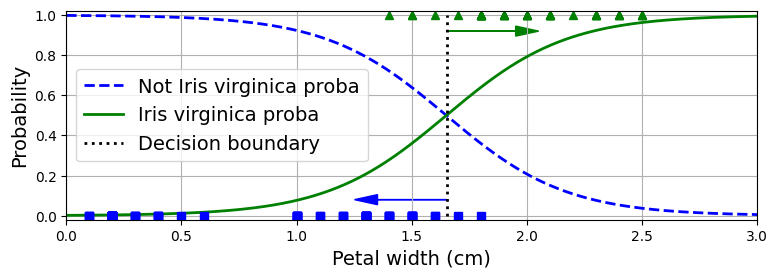

In [67]:
X_new = np.linspace(0, 3, 1000).reshape(-1, 1)  # reshape to get a column vector
y_proba = log_reg.predict_proba(X_new)
decision_boundary = X_new[y_proba[:, 1] >= 0.5][0, 0]

plt.figure(figsize=(8, 3))  # Formatação do Gráfico
plt.plot(X_new, y_proba[:, 0], "b--", linewidth=2,
         label="Not Iris virginica proba")
plt.plot(X_new, y_proba[:, 1], "g-", linewidth=2, label="Iris virginica proba")
plt.plot([decision_boundary, decision_boundary], [0, 1], "k:", linewidth=2,
         label="Decision boundary")

plt.arrow(x=decision_boundary, y=0.08, dx=-0.3, dy=0,
          head_width=0.05, head_length=0.1, fc="b", ec="b")
plt.arrow(x=decision_boundary, y=0.92, dx=0.3, dy=0,
          head_width=0.05, head_length=0.1, fc="g", ec="g")
plt.plot(X_train[y_train == 0], y_train[y_train == 0], "bs")
plt.plot(X_train[y_train == 1], y_train[y_train == 1], "g^")
plt.xlabel("Petal width (cm)")
plt.ylabel("Probability")
plt.legend(loc="center left")
plt.axis([0, 3, -0.02, 1.02])
plt.grid()
save_fig("logistic_regression_plot")

plt.show()

In [68]:
decision_boundary

np.float64(1.6516516516516517)

Agora, temos um Classificador que considera a Largura e a Altura da Pétala para fazer a classificação.

*Observação*

Assim como nos Modelos Lineares, a Regressão Logística também trabalha com Regularização, por Padrão, a classe `LogisticRegression` aplica a Regularização Ridge (L2), e o parâmetro `C` (o inverso do alpha), determina a taxa de regularização. Quanto maior o valor de `C`, menos o modelo é regularizado.

In [69]:
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = iris.target_names[iris.target] == 'virginica'

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

log_reg = LogisticRegression(C=2, random_state=42)
log_reg.fit(X_train, y_train)

LogisticRegression(C=2, random_state=42)

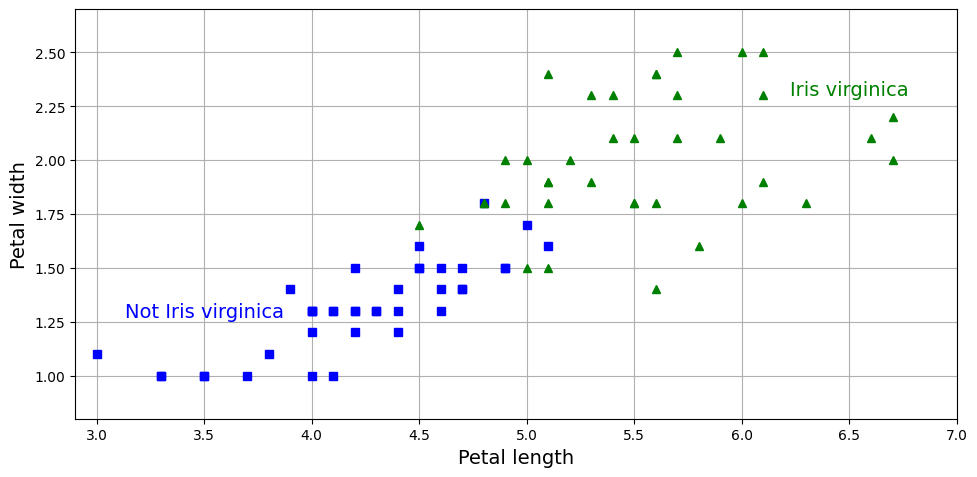

In [70]:
# for the contour plot
x0, x1 = np.meshgrid(np.linspace(2.9, 7, 500).reshape(-1, 1),
                     np.linspace(0.8, 2.7, 200).reshape(-1, 1))
X_new = np.c_[x0.ravel(), x1.ravel()]  # one instance per point on the figure

plt.figure(figsize=(10, 5))
plt.plot(X_train[y_train == 0, 0], X_train[y_train == 0, 1], "bs")
plt.plot(X_train[y_train == 1, 0], X_train[y_train == 1, 1], "g^")
plt.text(3.5, 1.27, "Not Iris virginica", color="b", ha="center")
plt.text(6.5, 2.3, "Iris virginica", color="g", ha="center")
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.axis([2.9, 7, 0.8, 2.7])
plt.grid()
save_fig("logistic_regression_iris_data")
plt.show()

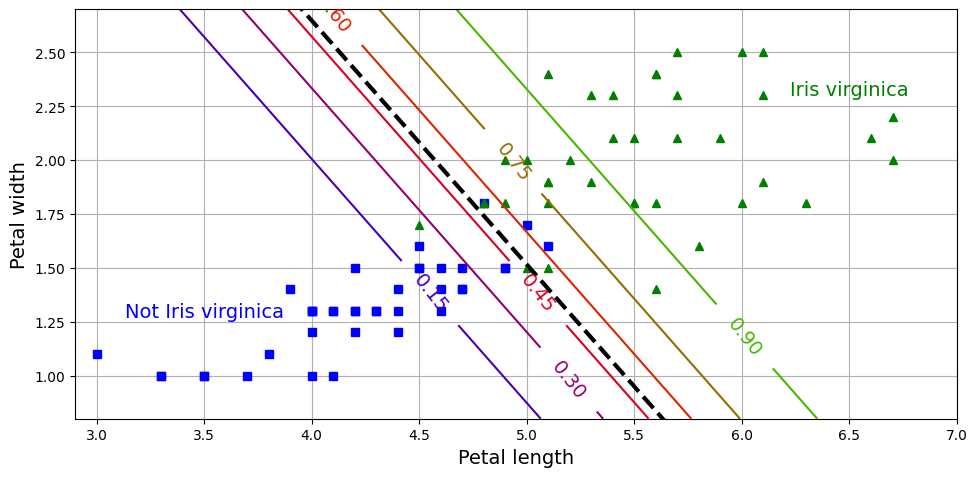

In [71]:
# for the contour plot
x0, x1 = np.meshgrid(np.linspace(2.9, 7, 500).reshape(-1, 1),
                     np.linspace(0.8, 2.7, 200).reshape(-1, 1))
X_new = np.c_[x0.ravel(), x1.ravel()]  # one instance per point on the figure
y_proba = log_reg.predict_proba(X_new)
zz = y_proba[:, 1].reshape(x0.shape)

# for the decision boundary
left_right = np.array([2.9, 7])
boundary = -((log_reg.coef_[0, 0] * left_right + log_reg.intercept_[0])
             / log_reg.coef_[0, 1])

plt.figure(figsize=(10, 5))
plt.plot(X_train[y_train == 0, 0], X_train[y_train == 0, 1], "bs")
plt.plot(X_train[y_train == 1, 0], X_train[y_train == 1, 1], "g^")
contour = plt.contour(x0, x1, zz, cmap=plt.cm.brg)
plt.clabel(contour, inline=1)
plt.plot(left_right, boundary, "k--", linewidth=3)
plt.text(3.5, 1.27, "Not Iris virginica", color="b", ha="center")
plt.text(6.5, 2.3, "Iris virginica", color="g", ha="center")
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.axis([2.9, 7, 0.8, 2.7])
plt.grid()
save_fig("logistic_regression_contour_plot")
plt.show()

### FIM DA 2ª DA DEMONSTRAÇÃO - voltar aos slides

#Métricas

## Calculando Acurácia com Validação Cruzada

Aqui faremos a validação cruzada utilizando a função `cross_val_score`do Scikit Learn. Que vai dividir os dados em 3 conjuntos *(folds)* diferentes, utilizando 1 conjunto diferente para validação a cada treinamento.

In [126]:
from sklearn.model_selection import cross_val_score

cross_val_score(log_reg, X_train, y_train, cv=3, scoring="accuracy")

array([0.97368421, 0.91891892, 0.97297297])

Aqui temos o "dummy classifier", que sempre retornara falso, devido a ser o valor mais comum. No caso False, pois 1/3 registros no dataset não são *Iris Virginica*. Observe a acurácia deste modelo, que é claramente inútil.

In [127]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train)
print(any(dummy_clf.predict(X_train)))

False


In [128]:
cross_val_score(dummy_clf, X_train, y_train, cv=3, scoring="accuracy")

array([0.65789474, 0.67567568, 0.64864865])

## Matrizes de Confusão

Primeiro, vamos utilizar a função `cross_val_predict` do Scikit Learn para dividir os dados de treinamento em 3 folds, treiná-los e armazenar os resultados das previsões feitas com o processo de validação cruzada.

In [129]:
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(log_reg, X_train, y_train, cv=3)

Agora, vamos utilizar a função `confusion_matrix`, também do Scikit Learn, para verificar quais resultados foram positivos e negativos para cada classificação realizada.

Antes de interpretar o resultado da Matriz de confusão, um conceito. Esta matriz exibe em suas linhas os dados das Classe Reais, Negativa e depois Positiva.

In [130]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_train, y_train_pred)
cm

array([[71,  3],
       [ 2, 36]])

A Saída da Matriz de Confusão pode ainda estar confusa, abaixo temos uma visualização mais gráfica.

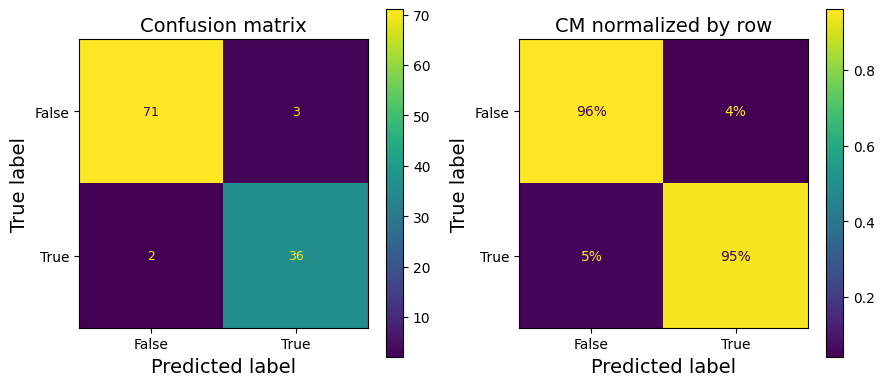

In [131]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))
plt.rc('font', size=9)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, ax=axs[0])
axs[0].set_title("Confusion matrix")
plt.rc('font', size=10)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, ax=axs[1],
                                        normalize="true", values_format=".0%")
axs[1].set_title("CM normalized by row")
save_fig("confusion_matrix_plot_1")
plt.show()

Se o modelo fosse perfeito, o resultado seria o que está abaixo:

In [132]:
y_train_perfect_predictions = y_train  # fazendo de conta, que o modelo é perfeito
confusion_matrix(y_train, y_train_perfect_predictions)

array([[74,  0],
       [ 0, 38]])

## Precisão (Precision) e Revocação (Recall)

A Matriz de Confusão fornece bastante informação, mas é confusa. Talvez você queira uma métrica mais concisa.

Abaixo vamos calcular a Precisão, que é uma taxa que indica o percentual de vezes que o modelo está certo quando diz que é uma *Iris Virginica*.

In [133]:
from sklearn.metrics import precision_score, recall_score

precision_score(y_train, y_train_pred)

0.9230769230769231

Abaixo vamos calcular a taxa de Revocação (Recall), que é uma taxa calculada para responder a seguinte pergunta: De todas as *"Iris Virginica"* testadas, quantos o modelo conseguiu encontrar?

In [134]:
recall_score(y_train, y_train_pred)

0.9473684210526315

Aqui vamos calcular o F1 Score, que é uma média harmonica da Precisão com o Recall. Esta métrica pune modelos em que somente a Precisão ou o Recall é muito bom, enquanto a outra métrica é ruim.

Imagine dois modelos:

🔹 Modelo A
- Precisão muito alta
- Recall muito baixo
- 👉 Só diz é *“Iris Virginica”* quando tem quase certeza, mas deixa passar muitos "Iris Virginica" reais

🔹 Modelo B
- Recall muito alto
- Precisão muito baixa
- 👉 Marca quase tudo como *“Iris Virginica”*, mas erra muito

Qual dos modelos é melhor? Dependendo do modelo, nenhum dos dois.

**O F1 Score é um equilíbrio entre Precisão e Recall.**

In [135]:
from sklearn.metrics import f1_score

f1_score(y_train, y_train_pred)

0.935064935064935

## Equilíbrio entre Precision e Revocação (Recall)

Aqui temos um exemplo simples de predição do modelo.

In [136]:
log_reg.predict([[4.8, 1.75]])

array([ True])

In [137]:
log_reg.predict_proba([[4.8, 1.75]])

array([[0.49413238, 0.50586762]])

Quando você usa um classificador, já aprendemos que ele não define diretamente em “classe 0 ou classe 1”. No caso da Regressão logistica, depende do valor calculado pela função Sigmoide.

Ele *"pensa"* primeiro em algo assim:

In [138]:
y_scores = log_reg.decision_function([[4.8, 1.75]])
y_scores

array([0.02347154])

Agora vamos ver o threshold, que indica o limite a partir do qual a amostra será classificada como *"Iris Virginica"*. Por padrão, esse valor é definido como 0 (correspondente ao 0,5 da função sigmoide).

Se aumentar o valor do threshold, o algoritmo será mais conservador e vai classificar menos valores como sendo o *"Iris Virginica"*, aumentando a Precisão e ao mesmo tempo, diminuindo o Recall.

Se diminuir o valor do threshold, o algoritmo será mais permissivo e vai classificar mais amostrar como sendo *"Iris Virginica"*, diminuindo a Precisão e ao mesmo tempo, aumentando o Recall.

Abaixo mostra um como isso ocorre, comparando o y_score (Pontuação de Decisão da seleção, contra o threshold).

In [139]:
threshold = 0
y_amostra_pred = (y_scores > threshold)

y_amostra_pred

array([ True])

Agora, considerando um threshold de "0.3"

In [140]:
threshold = 0.3
y_amostra_pred = (y_scores > threshold)
y_amostra_pred

array([False])

Abaixo, vamos utilizar o método de validação cruzada cross_val_predict para calcular as Pontuações de Decisão de todos os registros.

Na sequência, vamos utilizar o método precisison_recall_curve para, a partir das pontuações de decisão apuradas, calcular a Precisão e Recall para todos os limites (threshold) possiveis.

Na sequência, é plotado um gráfico, permitindo ter uma boa ideia de qual configuração de Limite você pode utilizar, para ter um melhor resultado, considerando a métrica que você está utilizando (Precisão, Recall ou F1 Score).

In [141]:
y_scores = cross_val_predict(log_reg, X_train, y_train, cv=3, method="decision_function")
y_scores

array([-1.28446416e+01, -1.28034978e+01,  9.14309362e-01, -1.37199184e+00,
       -1.06310004e+00, -1.26591810e+01, -1.25768935e+01, -4.87360204e+00,
        7.89215954e-03,  1.75869726e+00, -2.09294849e+00,  4.95141566e+00,
       -2.85504889e+00,  5.38373871e+00, -1.59859614e+00, -1.28446416e+01,
        5.42488245e+00, -3.80260984e+00, -1.28446416e+01, -1.28857853e+01,
       -1.10526927e+01, -5.40909813e+00,  1.52208962e-01, -1.15059013e+01,
       -1.23091455e+01, -1.13615845e+01, -2.85504889e+00, -1.25768935e+01,
       -3.08165319e+00,  5.87809106e+00, -1.28446416e+01, -2.58730084e+00,
        8.73165613e-01, -1.28446416e+01, -1.15539087e-01,  9.14309362e-01,
       -4.00301000e+00, -1.24986420e+00,  2.62397071e+00, -3.23891678e+00,
       -1.23376191e+01, -6.07452994e+00,  1.44980546e+00, -1.37348088e+01,
       -1.43266717e+01, -4.34017510e+00,  7.39188386e-01, -1.34388774e+01,
        2.81800398e+00, -1.34388774e+01, -1.21241550e+01,  4.02023284e-01,
       -6.70762646e+00,  

In [142]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train, y_scores)

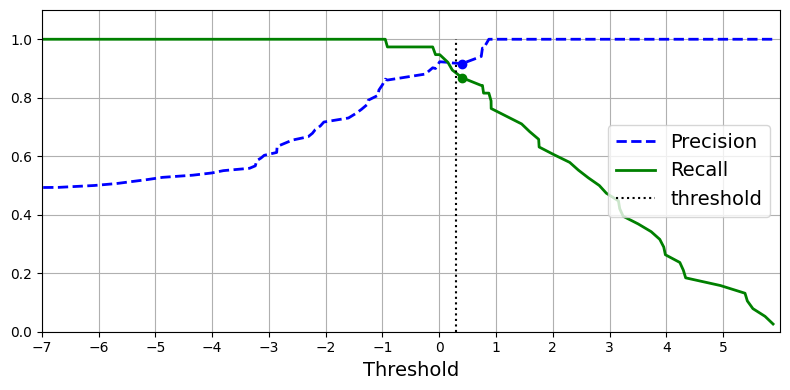

In [143]:
plt.figure(figsize=(8, 4))  # Código para formatação do gráfico
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.vlines(threshold, 0, 1.0, "k", "dotted", label="threshold")

# Código para formatação do gráfico
idx = (thresholds >= threshold).argmax()  # first index ≥ threshold
plt.plot(thresholds[idx], precisions[idx], "bo")
plt.plot(thresholds[idx], recalls[idx], "go")
plt.axis([-7, 6, 0, 1.1])
plt.xticks(np.arange(-7, 6, 1))
plt.grid()
plt.xlabel("Threshold")
plt.legend(loc="center right")
save_fig("precision_recall_vs_threshold_plot")

plt.show()

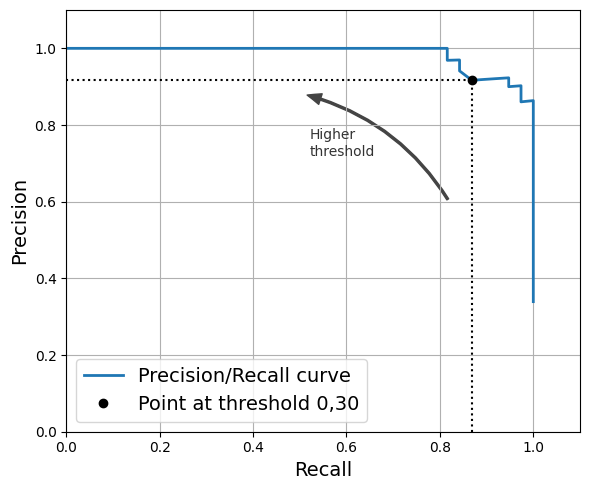

In [144]:
# Este código gera um gráfico diferente para visualização da curva de Precisão/Recall
import matplotlib.patches as patches

plt.figure(figsize=(6, 5))

plt.plot(recalls, precisions, linewidth=2, label="Precision/Recall curve")

plt.plot([recalls[idx], recalls[idx]], [0., precisions[idx]], "k:")
plt.plot([0.0, recalls[idx]], [precisions[idx], precisions[idx]], "k:")
plt.plot([recalls[idx]], [precisions[idx]], "ko",
         label="Point at threshold 0,30")
plt.gca().add_patch(patches.FancyArrowPatch(
    (0.82, 0.60), (0.51, 0.88),
    connectionstyle="arc3,rad=.2",
    arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",
    color="#444444"))
plt.text(0.52, 0.72, "Higher\nthreshold", color="#333333")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.axis([0, 1.1, 0, 1.1])
plt.grid()
plt.legend(loc="lower left")
save_fig("precision_vs_recall_plot")

plt.show()

O código abaixo identifica qual o Threshold mínimo para se obter uma precisão acima de 95%.

In [145]:
idx_for_95_precision = (precisions >= 0.95).argmax()
threshold_for_95_precision = thresholds[idx_for_95_precision]
threshold_for_95_precision

np.float64(0.7604738019999822)

In [146]:
y_train_pred_95 = (y_scores >= threshold_for_95_precision)
y_train_pred_95

array([False, False,  True, False, False, False, False, False, False,
        True, False,  True, False,  True, False, False,  True, False,
       False, False, False, False, False, False, False, False, False,
       False, False,  True, False, False,  True, False, False,  True,
       False, False,  True, False, False, False,  True, False, False,
       False, False, False,  True, False, False, False, False,  True,
        True,  True,  True, False, False, False, False,  True, False,
       False, False, False,  True, False,  True,  True, False, False,
       False, False, False,  True, False,  True, False,  True, False,
       False, False, False, False, False, False, False,  True,  True,
       False, False,  True,  True, False,  True, False, False,  True,
        True, False,  True, False, False,  True,  True, False, False,
       False, False, False,  True])

In [147]:
precision_score(y_train, y_train_pred_95)

0.9696969696969697

O custo, para um Resultado de uma precisão acima de 95%, é um Recall em 84,21%.

In [148]:
recall_at_95_precision = recall_score(y_train, y_train_pred_95)
recall_at_95_precision

0.8421052631578947

Abaixo temos os Gráficos mostrando como seria o comportamento aplicando o Threshold que atinge 95% de Precisão!

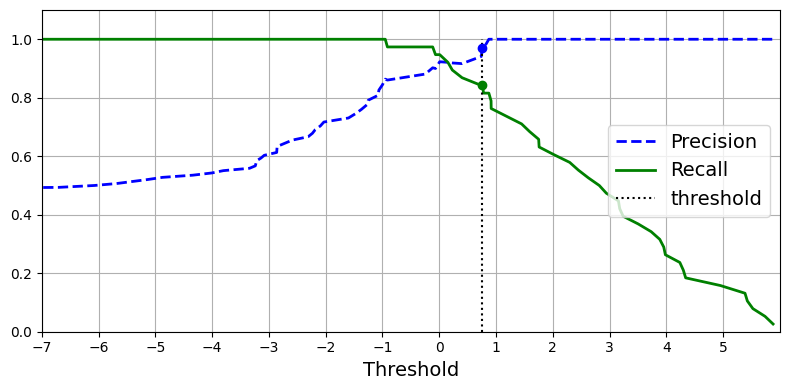

In [149]:
plt.figure(figsize=(8, 4))  # Código para formatação do gráfico
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.vlines(threshold_for_95_precision, 0, 1.0, "k", "dotted", label="threshold")

# Código para formatação do gráfico
idx = (thresholds >= threshold_for_95_precision).argmax()  # first index ≥ threshold
plt.plot(thresholds[idx], precisions[idx], "bo")
plt.plot(thresholds[idx], recalls[idx], "go")
plt.axis([-7, 6, 0, 1.1])
plt.xticks(np.arange(-7, 6, 1))
plt.grid()
plt.xlabel("Threshold")
plt.legend(loc="center right")
save_fig("precision_recall_vs_threshold_plot")

plt.show()

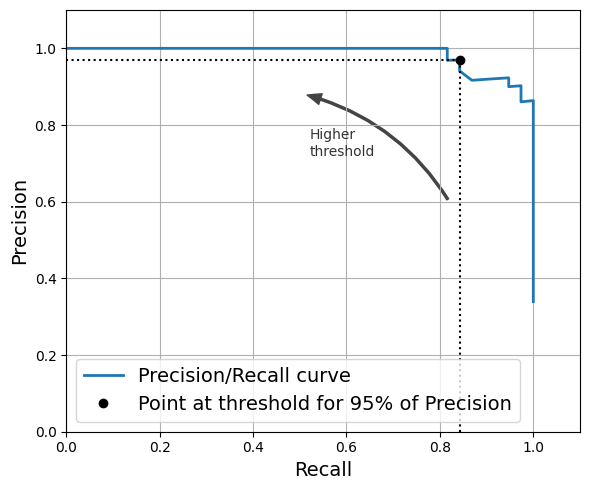

In [150]:
# Este código gera um gráfico diferente para visualização da curva de Precisão/Recall
import matplotlib.patches as patches

plt.figure(figsize=(6, 5))

plt.plot(recalls, precisions, linewidth=2, label="Precision/Recall curve")

plt.plot([recalls[idx_for_95_precision], recalls[idx_for_95_precision]], [0., precisions[idx_for_95_precision]], "k:")
plt.plot([0.0, recalls[idx_for_95_precision]], [precisions[idx_for_95_precision], precisions[idx_for_95_precision]], "k:")
plt.plot([recalls[idx_for_95_precision]], [precisions[idx_for_95_precision]], "ko",
         label="Point at threshold for 95% of Precision")
plt.gca().add_patch(patches.FancyArrowPatch(
    (0.82, 0.60), (0.51, 0.88),
    connectionstyle="arc3,rad=.2",
    arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",
    color="#444444"))
plt.text(0.52, 0.72, "Higher\nthreshold", color="#333333")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.axis([0, 1.1, 0, 1.1])
plt.grid()
plt.legend(loc="lower left")
save_fig("precision_vs_recall_plot")

plt.show()

##A Curva ROC

A Curva ROC (Receiver Operating Characteristic ou Característica de Operação do Operador) mostra como o recall aumenta (ou diminui) conforme o modelo passa a aceitar mais ou menos exemplos como positivos, revelando o trade-off entre detectar positivos e gerar falsos alarmes.

Cálculo da Curva ROC

O classificador gera um score (via decision_function).

Threshold alto → modelo só diz “SIM” quando tem muita certeza
Threshold baixo → modelo diz “SIM” com mais facilidade
Cada threshold gera:

Um Recall (TPR)
Uma Taxa de Falsos Positivos (FPR)
A Curva ROC conecta esses pontos.

In [151]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train, y_scores)

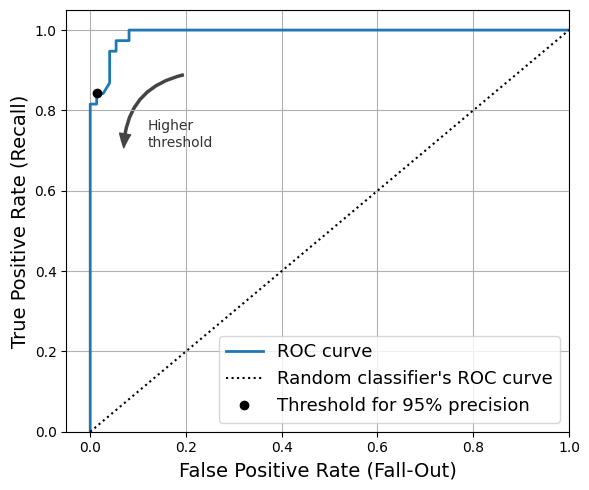

In [152]:
idx_for_threshold_at_95 = (thresholds <= threshold_for_95_precision).argmax()
tpr_95, fpr_95 = tpr[idx_for_threshold_at_95], fpr[idx_for_threshold_at_95]

plt.figure(figsize=(6, 5))  # extra code – not needed, just formatting
plt.plot(fpr, tpr, linewidth=2, label="ROC curve")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")
plt.plot([fpr_95], [tpr_95], "ko", label="Threshold for 95% precision")

# extra code – just beautifies and saves Figure 3–7
plt.gca().add_patch(patches.FancyArrowPatch(
    (0.20, 0.89), (0.07, 0.70),
    connectionstyle="arc3,rad=.4",
    arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",
    color="#444444"))
plt.text(0.12, 0.71, "Higher\nthreshold", color="#333333")
plt.xlabel('False Positive Rate (Fall-Out)')
plt.ylabel('True Positive Rate (Recall)')
plt.grid()
plt.axis([-0.05, 1, 0, 1.05])
plt.legend(loc="lower right", fontsize=13)
save_fig("roc_curve_plot")

plt.show()

**AUC-ROC**

Abaixo é calculado o AUC_ROC, que indica o quanto o modelo é eficiente em separar as classes. Ele mede a eficiência do modelo, independente do Threshold.

AUC -> Area Under the Curve / Área sob a Curva

O AUC é a probabilidade de o modelo dar um score maior para um exemplo positivo do que para um exemplo negativo escolhido ao acaso.

Exemplo:

AUC = 0.991
👉 99,1% das vezes, uma *“Iris Virginica”* real recebe um score maior que um *“Não Iris Virginica”*.

In [153]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_train, y_scores)

np.float64(0.9919985775248934)

### FIM DA 3ª DA DEMONSTRAÇÃO - voltar aos slides

#Classificação Multiclasse

## Regressão Softmax

O modelo da Regressão Logística pode ser generalizado para dar suporte diretamente a várias classes, sem a necessidade de treinar e combinar inúmeros classificadores binários. Esta é a **Regressão Softmax**.


Na Regressão Softmax, cada classe terá a sua própria probabilidade. Ao fazer a predição de uma determinada planta, o modelo calcula um score para cada classe e, em seguida, utiliza a função Softmax para transformar esses scores em probabilidades.

A partir dessas probabilidades, o modelo seleciona a classe com maior valor para realizar a predição

In [ ]:
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = iris["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

softmax_reg = LogisticRegression(C=30, random_state=42)
softmax_reg.fit(X_train, y_train)

LogisticRegression(C=30, random_state=42)

In [ ]:
softmax_reg.predict([[5, 2]])

array([2])

In [ ]:
softmax_reg.predict_proba([[5, 2]]).round(2)

array([[0.  , 0.04, 0.96]])

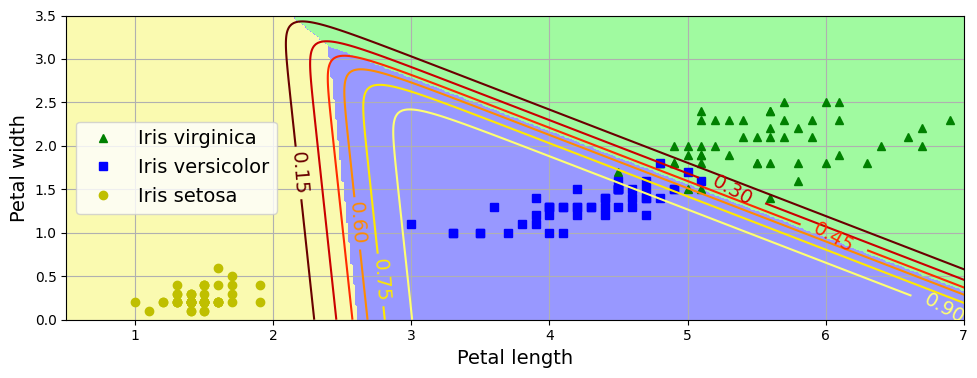

In [ ]:
from matplotlib.colors import ListedColormap

custom_cmap = ListedColormap(["#fafab0", "#9898ff", "#a0faa0"])

x0, x1 = np.meshgrid(np.linspace(0, 8, 500).reshape(-1, 1),
                     np.linspace(0, 3.5, 200).reshape(-1, 1))
X_new = np.c_[x0.ravel(), x1.ravel()]

y_proba = softmax_reg.predict_proba(X_new)
y_predict = softmax_reg.predict(X_new)

zz1 = y_proba[:, 1].reshape(x0.shape)
zz = y_predict.reshape(x0.shape)

plt.figure(figsize=(10, 4))
plt.plot(X[y == 2, 0], X[y == 2, 1], "g^", label="Iris virginica")
plt.plot(X[y == 1, 0], X[y == 1, 1], "bs", label="Iris versicolor")
plt.plot(X[y == 0, 0], X[y == 0, 1], "yo", label="Iris setosa")

plt.contourf(x0, x1, zz, cmap=custom_cmap)
contour = plt.contour(x0, x1, zz1, cmap="hot")
plt.clabel(contour, inline=1)
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.legend(loc="center left")
plt.axis([0.5, 7, 0, 3.5])
plt.grid()
save_fig("softmax_regression_contour_plot")
plt.show()

### FIM DA 4ª DA DEMONSTRAÇÃO - voltar aos slides

# Exercícios

**Contexto de Negócio**

Você recebeu a informação, que é extremamente relevante a identificação das plantas da espécie *Iris Versicolor*, e te foi solicitado a criação de um modelo capaz de identificar as plantas desta espécie entre as demais plantas *Iris*.

A orientação geral, é que sejam identificadas a maior quantidade possível de plantas "Iris Versicolor", preferencialmente que entre as plantas avaliadas, o modelo seja capaz de identificar acima de 93% das plantas *Iris Versicolor* corretamente.

---

1. Prepare um novo modelo baixando o Dataset Iris, faça a separação entre dados de Treino e Validação. Treine um modelo considerando considerando as características *sepal length*, *petal length* e *petal width*.

Calcule previsões, utilizando informações do Conjunto de Validação do Modelo.

In [1]:
# RESOLUÇÃO EXERCÍCIO 1

2. Considerando o modelo treinado. Faça 3 exemplos de treinamento diferentes, com valores diferentes para o hiper parametro "c". Utilize os valores:

 - c = 0.01
 - c = 1
 - c = 100

Calcule e compare a acurácia entre os modelos

In [ ]:
# RESOLUÇÃO EXERCÍCIO 2

***Reflexão*** → O número de positivos aumentou ou diminuiu com as mudanças?

3. Considerando o Modelo com o valor padrão para o hiper parametro "c", calcule as informações de Acurácia, Precisão e Recall para o modelo desenvolvido.

Observe se está sendo atendido ao objetivo de negócio com a sua versão atual.

In [2]:
# RESOLUÇÃO EXERCÍCIO 3

4. Se necessário, ajuste o Threshold do Modelo para atender aos objetivos de negócio. Se não é necessário ajuste, justifique o motivo.

In [ ]:
# RESOLUÇÃO EXERCÍCIO 4

5. Faça uma segunda versão de ajuste do Threshold, buscando a maior precisão possível, mantendo o Recall acima de 82%.

In [ ]:
# RESOLUÇÃO EXERCÍCIO 5